<div style="display:flex; align-items:center; gap:18px; text-align:left">
  <img src="https://sebastiancontz.github.io/ust-diplomado-ia-curso-ml/assets/logo_ust.png" width="100">
  <div>
    <p>Diplomado en Inteligencia Artificial para los Negocios</p>
    <p>Facultad de Ingeniería y Negocios</p>
    <p>Módulo 2: Fundamentos de Machine Learning y herramientas Low Code</p>
    <p>Semana 04: Algoritmos de Clasificación</p>
  </div>
</div>

# 04 · Algoritmos de Clasificación

En la Clase 3 predijimos un **número** (el precio en UF). Hoy predecimos una **categoría**: ¿este
cliente **se va a fugar** o no? Es el mismo flujo de siempre —preparar, comparar, evaluar,
interpretar—, pero cambia el **tipo de problema** y, con él, las **métricas**.

El mensaje central de la clase: con clases desbalanceadas, **el *accuracy* (exactitud) no basta**.
Vamos a leer la **matriz de confusión**, la **precision**, el **recall** y el **umbral** para
**decidir** según el costo de cada error. Como siempre, PyCaret hace el trabajo pesado; nosotros
interpretamos y decidimos.

## Preparación del entorno

Instalamos las librerías necesarias para ejecutar el notebook en Colab o en local. La salida queda
oculta para no llenar la pantalla con texto técnico.

In [1]:
%%capture
!pip install -q pycaret==4.0.0a8 plotly ipywidgets xgboost catboost lightgbm

## Setup técnico

Importaciones y configuración general. No es contenido propio de clasificación; solo deja el entorno
listo para que las celdas importantes se concentren en interpretar el modelo.

In [2]:
%matplotlib inline
import os, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
from IPython.utils import io
from IPython.display import HTML
from sklearn import set_config
from sklearn.utils import estimator_html_repr

# evita que Jupyter/GitHub muestre el pipeline como HTML enorme.
set_config(display='text')

## Cargar datos

Usaremos `clientes.csv`: **~2.000 clientes** de una empresa de telecomunicaciones (datos sintéticos,
generados para el curso). Cada fila es un cliente; la columna `fuga` (*churn*) indica si se fue
(`si`) o se quedó (`no`). Esa es nuestra **variable objetivo** (*target*).

In [3]:
REPO = 'https://raw.githubusercontent.com/sebastiancontz/ust-fundamentos-machine-learning-colab/main/ediciones/2026/datasets/'
BASE = '../datasets/' if os.path.exists('../datasets') else REPO

df = pd.read_csv(BASE + 'clientes.csv')
print('Filas y columnas:', df.shape)
df.head()

Filas y columnas: (2000, 6)


,edad,antiguedad_meses,plan,cargo_mensual,llamadas_soporte,fuga
0,19,36,Estándar,55,1,no
1,73,1,Básico,34,6,si
2,42,11,Básico,16,3,si
3,31,35,Básico,25,1,no
4,70,5,Básico,33,4,no


## El problema: ¿se fuga el cliente?

Antes de modelar, miremos **cuántos** clientes se fugan. Esta proporción es la clave de toda la clase:
si una categoría es **rara**, el *accuracy* puede engañarnos.

<!-- migracion-modular: api-nuevas -->
## APIs de pandas que se incorporan

- `drop` excluye columnas elegidas; `get_dummies` transforma categorías en indicadores 0/1.
- `map` recodifica valores con una tabla explícita y `value_counts` cuenta las categorías observadas.


In [4]:
conteo = df['fuga'].value_counts().rename_axis('fuga').reset_index(name='clientes')
conteo['porcentaje'] = (conteo['clientes'] / len(df) * 100).round(1)

fig = px.bar(conteo, x='fuga', y='clientes', color='fuga', text='porcentaje',
             color_discrete_map={'no': '#1E90FF', 'si': '#e63946'},
             title='¿Cuántos clientes se fugan?')
fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.update_layout(showlegend=False, height=380)
fig.show()

print('Proporción de fuga:')
print((df['fuga'].value_counts(normalize=True) * 100).round(1))

Proporción de fuga:
fuga
no    82.2
si    17.8
Name: proportion, dtype: float64


Las clases están **desbalanceadas**: cerca del **82%** no se fuga y solo **~18%** sí. Esto tiene una
consecuencia inmediata. Un modelo "tonto" que dijera **siempre "no se fuga"** acertaría ~82% de las
veces… **sin detectar ni una sola fuga**. Ese es el peligro de mirar solo el *accuracy*.

<p align="center"></p>

La clase que nos importa (la fuga) es **la minoritaria**. Por eso vamos a necesitar métricas que
miren **cuántas fugas capturamos**, no solo cuántas predicciones acertamos en total.

## 1. Preparar el experimento

Con PyCaret, preparar los datos para clasificar es **una línea**. Al crear el
`ClassificationExperiment` y llamar `.fit(df)`, PyCaret automáticamente **separa** entrenamiento y
prueba, **codifica** las categóricas, **imputa** faltantes y —porque lo pedimos— **escala** las
variables numéricas.

Dos opciones importantes para esta clase:

- **`normalize=True`** → estandariza las variables numéricas (las lleva a una escala comparable).
  Ayuda a modelos sensibles a la escala como la regresión logística; a los árboles no les afecta.
- **`fold_strategy='stratifiedkfold'`** → la validación cruzada mantiene la **misma proporción de
  fuga** (~18%) en cada pliegue. Así ningún pliegue queda "sin fugas" y la evaluación es honesta.
  (PyCaret ya estratifica por defecto en clasificación; aquí lo dejamos **explícito** para verlo.)

In [5]:
from pycaret.tasks import ClassificationExperiment

exp = ClassificationExperiment(
    target='fuga',
    session_id=42,
    train_size=0.70,
    fold=5,
    normalize=True,
    fold_strategy='stratifiedkfold',
).fit(df)

print('Entrenamiento:', exp.X_train.shape, '| Prueba (holdout):', exp.X_test.shape)

Entrenamiento: (1400, 5) | Prueba (holdout): (600, 5)


## 2. Comparar modelos

`compare_models` entrena varias **familias** de modelos y las rankea con **validación cruzada
estratificada**. Ordenamos por **AUC** (no por *accuracy*): con clases desbalanceadas, el AUC —qué tan
bien el modelo **ordena** los clientes por riesgo— es una referencia más estable que el porcentaje de
aciertos.

In [6]:
# familias de la clase: logística, árbol y ensambles (todas entregan probabilidades).
# gbc = gradient boosting; et = extra trees; rf = random forest; más XGBoost, CatBoost y LightGBM.
modelos_clase = ['lr', 'dt', 'rf', 'et', 'gbc', 'xgboost', 'catboost', 'lightgbm']

with io.capture_output():
    res = exp.compare_models(include=modelos_clase, sort='AUC', errors='ignore')
res.leaderboard

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,lr,0.8457,0.8089,0.328,0.6338,0.4319,0.3528,0.3787
1,gbc,0.8321,0.7861,0.288,0.5602,0.3799,0.2942,0.3163
2,catboost,0.8343,0.7852,0.280,0.5757,0.3758,0.2933,0.3191
3,rf,0.8357,0.7634,0.296,0.5799,0.3905,0.3073,0.3311
4,lightgbm,0.8157,0.7622,0.308,0.4752,0.3724,0.2706,0.2799
5,xgboost,0.8057,0.7504,0.288,0.4359,0.3455,0.2373,0.2449
6,et,0.8171,0.7471,0.268,0.4843,0.3416,0.2461,0.2621
7,dt,0.7614,0.6075,0.368,0.3401,0.3521,0.2065,0.2076


### Cómo leer el *leaderboard*

Cada fila es un modelo; cada columna, una **métrica** (promedio de la validación cruzada). Las de
clasificación responden preguntas de negocio distintas:

- **Accuracy** — de todas las predicciones, ¿qué proporción acertó. Engaña con desbalance.
- **AUC** — qué tan bien **ordena** por riesgo (0,5 = azar; 1 = perfecto). Sortea aquí.
- **Recall** — de las fugas reales, ¿a cuántas **capturó**. Clave cuando dejar pasar un caso es caro.
- **Prec.** (precision) — de las que marcó como fuga, ¿cuántas lo eran. Confiabilidad de la alarma.
- **F1** — equilibrio entre precision y recall.
- **Kappa** (kappa de Cohen) — cuánto **mejora respecto a acertar por puro azar**, descontando la
  "suerte" que regala el desbalance. Va de **0** (como el azar) a **1** (perfecto); puede ser negativo
  (peor que el azar).
- **MCC** (coeficiente de correlación de Matthews) — resume las **cuatro celdas** de la matriz de
  confusión en un número de **−1 a 1** (**1** = perfecto, **0** = azar, **−1** = todo al revés).

> Las dos últimas, **Kappa** y **MCC**, son **resúmenes en un solo número** diseñados para **no dejarse
> engañar por el desbalance** (a diferencia del accuracy): solo dan valores altos si el modelo acierta
> bien en **ambas** clases. No son el foco del curso, pero es útil saber qué miden por si aparecen.

> **Nota sobre SVM.** En las diapositivas vimos el SVM como modelo de clasificación. La versión lineal
> de PyCaret (`'svm'`) **no entrega probabilidades**, así que no produce AUC ni curva ROC; por eso la
> galería de arriba usa modelos que sí las dan. Puedes agregarlo en los ejercicios para verlo.

### Un paréntesis: ¿por qué estratificar los pliegues?

Recién rankeamos con **validación cruzada estratificada**. PyCaret la usa **por defecto** en
clasificación, así que activar o no `fold_strategy='stratifiedkfold'` **no cambia** el *leaderboard*
—por eso no "se ve" el efecto ahí—. Pero conviene entender **qué nos ahorra**.

La validación cruzada parte los datos en **pliegues**. Si el reparto es **aleatorio** (KFold), con una
clase rara un pliegue puede quedar **casi sin fugas** por azar → esa ronda evalúa mal. La versión
**estratificada** fuerza que **cada pliegue conserve la misma proporción** de fuga que el total.

Veámoslo con una **muestra pequeña** (150 clientes), que es donde más se nota: comparamos el **% de
fuga en cada pliegue** con reparto aleatorio y con reparto estratificado.

In [7]:
from sklearn.model_selection import KFold, StratifiedKFold
import numpy as np

peq = df.sample(150, random_state=1)                 # muestra pequeña
y = (peq['fuga'] == 'si').astype(int).values          # 1 = fuga, 0 = no

def pct_fuga_por_pliegue(splitter):
    return [round(y[test].mean() * 100, 1) for _, test in splitter.split(np.zeros(len(y)), y)]

comparacion = pd.DataFrame({
    'Pliegue': [str(i + 1) for i in range(5)],
    'KFold (aleatorio) % fuga': pct_fuga_por_pliegue(KFold(5, shuffle=True, random_state=1)),
    'StratifiedKFold % fuga':   pct_fuga_por_pliegue(StratifiedKFold(5, shuffle=True, random_state=1)),
})
print(f'Proporción real de fuga en la muestra: {y.mean() * 100:.1f}%')
comparacion

Proporción real de fuga en la muestra: 18.7%


,Pliegue,KFold (aleatorio) % fuga,StratifiedKFold % fuga
0,1,16.7,16.7
1,2,6.7,16.7
2,3,23.3,20.0
3,4,20.0,20.0
4,5,26.7,20.0


Con el reparto **aleatorio**, la fuga salta entre pliegues (uno queda cerca de **7%** y otro sobre
**26%**: casi 4× de diferencia); una ronda entrena/evalúa con muy pocas fugas y da una foto **engañosa**.
Con **estratificación**, todos los pliegues quedan cerca del **~18%** real → la evaluación es **pareja y
honesta**. En datasets grandes casi da lo mismo; en los **pequeños o muy desbalanceados**, es la
diferencia entre confiar o no en el resultado. Por eso PyCaret la deja **activada por defecto**.

## 3. El "modelo tonto": por qué el *accuracy* no basta

Antes de celebrar el *accuracy* del mejor modelo, comparémoslo con un **baseline** que **siempre
predice la clase mayoritaria** ("no se fuga"). Si nuestro modelo no le gana claramente, no está
aportando valor.

In [8]:
# 'dummy' = clasificador ingenuo que predice siempre la clase más frecuente.
with io.capture_output():
    tonto = exp.create_model('dummy')
metricas_tonto = exp.pull()
metricas_tonto

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold 0,0.8214,0.5,0.0,0.0,0.0,0.0,0.0
Fold 1,0.8214,0.5,0.0,0.0,0.0,0.0,0.0
Fold 2,0.8214,0.5,0.0,0.0,0.0,0.0,0.0
Fold 3,0.8214,0.5,0.0,0.0,0.0,0.0,0.0
Fold 4,0.8214,0.5,0.0,0.0,0.0,0.0,0.0
Mean,0.8214,0.5,0.0,0.0,0.0,0.0,0.0
Std,0.0000,0.0,0.0,0.0,0.0,0.0,0.0


Fíjate en el **Accuracy** del modelo tonto: es alto (~82%) **solo** porque casi todos los clientes
no se fugan. Pero su **Recall es 0**: no detecta **ninguna** fuga. Un 82% que no sirve para nada.
Ese es exactamente el punto: **el accuracy alto puede esconder un modelo inútil**. Por eso miramos
recall, precision y la matriz de confusión.

## 4. El mejor modelo

Tomamos el mejor modelo del *leaderboard* (el de mayor AUC) y lo miramos por dentro.

In [9]:
mejor = res.best
# representación HTML interactiva del pipeline de scikit-learn (preprocesamiento + modelo).
HTML(estimator_html_repr(mejor))

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['edad','antiguedad_meses','plan','cargo_mensual','llamadas_soporte']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical_pipeline', ...), ('categorical_pipeline', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is e

## 5. La matriz de confusión

La tabla base de **aciertos y errores**. Cruza lo que el modelo predijo con lo que pasó en realidad;
de aquí salen todas las métricas.

<p align="center"></p>

In [10]:
fig = exp.plot_model(mejor, plot='confusion_matrix')
# escala de color más legible (claro -> azul medio; el texto oscuro se lee en todas las celdas)
fig.update_traces(colorscale=[[0.0, '#e8f1fa'], [1.0, '#5a9bd4']],
                  textfont={'size': 18, 'color': '#12354f'})
fig.show()

Lee la matriz pensando en el negocio:

- **Verdaderos positivos (VP)** — fugas que **cazamos** (podemos intentar retenerlas).
- **Falsos negativos (FN)** — fugas que **se nos escaparon** (dijimos "se queda" y se fue). Suele ser
  el error **más caro**: perder al cliente.
- **Falsos positivos (FP)** — **falsas alarmas** (dijimos "se fuga" y se quedaba). Cuestan una llamada
  o un descuento de más.
- **Verdaderos negativos (VN)** — clientes tranquilos que identificamos bien.

## 6. Precision y recall: el intercambio

La **curva precision-recall** muestra el **intercambio** entre las dos métricas a medida que movemos el
umbral: subir el recall (capturar más fugas) suele **bajar** la precision (más falsas alarmas), y al
revés. Nos interesa la clase **"si"** (la fuga): ¿qué tan confiable es la alarma (**precision**) y qué
proporción de fugas capturamos (**recall**)?

In [11]:
exp.plot_model(mejor, plot='pr')

## 7. La curva ROC y el AUC

Cada punto de la **curva ROC** corresponde a un **umbral distinto**: muestra el intercambio entre
capturar fugas (eje vertical) y generar falsas alarmas (eje horizontal). El **AUC** es el área bajo esa
curva: cuanto más se acerca la curva a la esquina superior izquierda, mejor ordena el modelo.

In [12]:
exp.plot_model(mejor, plot='auc')

## 8. El umbral de decisión

El modelo entrega una **probabilidad** de fuga; el **umbral** la convierte en un "sí/no" (por defecto,
0,5). Mover el umbral es una **palanca de negocio**: bajarlo captura más fugas (más recall) a costa de
más falsas alarmas; subirlo hace lo contrario. Este gráfico muestra cómo cambian las métricas según
dónde pongamos el corte.

In [13]:
exp.plot_model(mejor, plot='threshold')

¿Dónde poner el corte? Depende del **costo** de cada error. Si perder un cliente (FN) es mucho más
caro que una llamada de más (FP) —y una campaña de retención es barata—, conviene **bajar** el umbral
para **cazar más fugas**, aceptando algunas falsas alarmas.

## 9. ¿Cómo "piensa" un árbol por dentro?

Uno de los modelos de la galería es el **árbol de decisión**. Su gran ventaja es que se puede **ver**:
son preguntas **sí/no** encadenadas. Entrenamos un árbol **pequeño** (profundidad 3), **solo para
visualizar** su estructura —no es el modelo final, sino una ventana a cómo deciden los árboles (y, por
dentro, los ensambles como random forest).

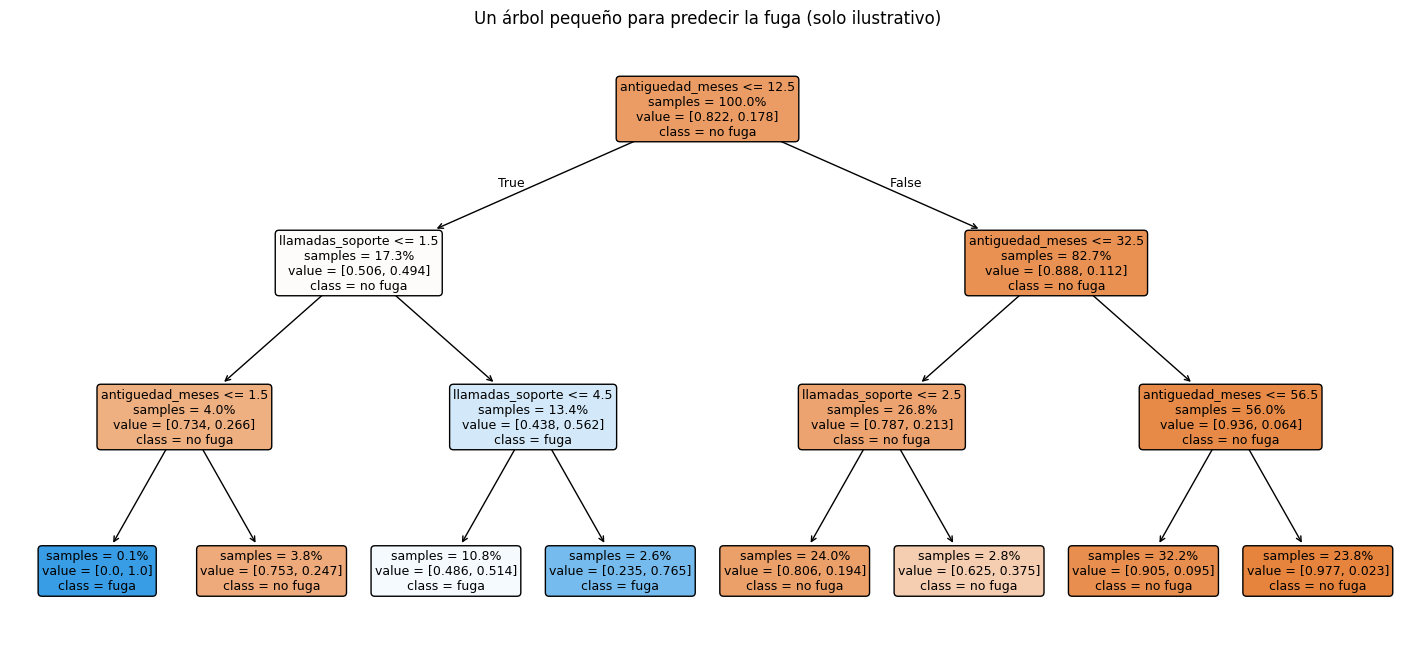

In [14]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# preparación mínima solo para el dibujo: convertir 'plan' a columnas 0/1 y la fuga a 1/0.
X_demo = pd.get_dummies(df.drop(columns='fuga'), columns=['plan'])
y_demo = (df['fuga'] == 'si').astype(int)

arbol_demo = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_demo, y_demo)

plt.figure(figsize=(18, 8))
plot_tree(arbol_demo, feature_names=list(X_demo.columns), class_names=['no fuga', 'fuga'],
          filled=True, rounded=True, proportion=True, impurity=False, fontsize=9)
plt.title('Un árbol pequeño para predecir la fuga (solo ilustrativo)')
plt.show()

Cada **caja** es una pregunta sobre una variable (por ejemplo, *¿antigüedad ≤ 12 meses?*). Según la
respuesta, bajas por la izquierda (sí) o la derecha (no) hasta una **hoja**, que da la predicción. Las
cajas coloreadas hacia un lado indican grupos donde domina "fuga" o "no fuga". Así de legible es un
árbol: por eso es tan fácil de **explicar a gerencia**. Un árbol solo se sobreajusta; los **ensambles**
combinan muchos para predecir mejor.

## 10. El examen final: el conjunto de prueba

Hasta aquí evaluamos con **validación cruzada** sobre el entrenamiento. Ahora el examen definitivo:
el **conjunto de prueba** (holdout) que PyCaret apartó y el modelo **nunca vio**. Calculamos las
métricas que de verdad importan con desbalance —**accuracy, recall y precision de la fuga**— y las
comparamos con el *leaderboard*: si se parecen, el modelo **generaliza** (no memorizó).

In [15]:
from sklearn.metrics import accuracy_score, recall_score, precision_score

with io.capture_output():
    pred = exp.predict_model(mejor)          # predice sobre el holdout

p = pred.predictions.copy()
# la etiqueta predicha viene como 1 = fuga / 0 = no fuga; la traducimos a "si"/"no"
p['prediccion'] = p['prediction_label'].map({1: 'si', 0: 'no'})

print(f'Accuracy:           {accuracy_score(p["fuga"], p["prediccion"]):.1%}')
print(f'Recall (fugas):     {recall_score(p["fuga"], p["prediccion"], pos_label="si"):.1%}')
print(f'Precision (fugas):  {precision_score(p["fuga"], p["prediccion"], pos_label="si"):.1%}')

Accuracy:           82.8%
Recall (fugas):     24.3%
Precision (fugas):  54.2%


Fíjate en el **recall**: al umbral por defecto (0,5), el modelo captura **solo una parte** de las
fugas —el resto se le escapa (falsos negativos)—, aunque el accuracy se vea alto. Ahí es donde **bajar
el umbral**, si el negocio lo justifica, nos permite **cazar más** fugas a costa de más falsas alarmas.

Y así se ven las predicciones cliente por cliente: la **probabilidad de fuga** es el riesgo que estima
el modelo, y la **predicción** es la decisión que resulta de aplicarle el **umbral 0,5** (si la
probabilidad supera 0,5 → "si"). Esa probabilidad es justo lo que usaríamos para **ordenar** a los
clientes por riesgo y **priorizar** las acciones de retención.

In [16]:
tabla = p[['fuga', 'prediccion', 'prediction_score']].head(10).rename(columns={
    'fuga': 'fuga_real', 'prediccion': 'predicción', 'prediction_score': 'probabilidad de fuga'})
tabla

,fuga_real,predicción,probabilidad de fuga
1830,no,no,0.3962
830,no,no,0.2187
1980,no,no,0.2051
1154,si,no,0.3408
1570,no,no,0.3469
797,no,no,0.3013
1397,no,no,0.0185
875,no,no,0.0556
484,no,no,0.0255
1807,no,no,0.0269


## 11. Ahora tú

Prueba y **observa cómo cambian las decisiones** (las soluciones se publican después):

1. Vuelve a comparar ordenando por **recall**: `exp.compare_models(include=modelos_clase, sort='Recall')`.
   ¿Cambia el modelo ganador? ¿En qué situación de negocio priorizarías el recall?
2. Agrega el **SVM** a la galería: `exp.compare_models(include=modelos_clase + ['svm'], sort='Accuracy')`.
   ¿Qué muestra su columna **AUC** y por qué (pista: probabilidades)?
3. Crea un solo modelo y mira su matriz: `logistica = exp.create_model('lr').pipeline` y luego
   `exp.plot_model(logistica, plot='confusion_matrix')`. ¿Comete más falsos negativos o falsos positivos?
4. Compara el **Accuracy** del "modelo tonto" con el del mejor modelo. En una frase para la gerencia:
   ¿por qué el accuracy alto del tonto **no** sirve?
5. Piensa en el **umbral**: si una campaña de retención cuesta muy poco y perder un cliente es carísimo,
   ¿subirías o bajarías el corte de 0,5? ¿Qué métrica esperarías mejorar?

---

**Síntesis.** Clasificar es predecir una **categoría**. Comparamos familias de modelos (logística,
árbol, ensambles) con un *leaderboard* de **validación cruzada estratificada**, y descubrimos que el
**accuracy no basta**: un modelo tonto lo infla sin detectar ni una fuga. Por eso leímos la **matriz
de confusión**, la **precision** y el **recall**, la **curva ROC / AUC**, y ajustamos el **umbral**
según el **costo** de cada error. Lo esencial no es el código, sino **interpretar y decidir** —y
comunicar por qué un modelo sirve (o no) para el negocio.

Repasa con la **guía de estudio** y las **tarjetas** de la clase.

<!-- migracion-modular: atribucion-datos -->
## Atribución de datos

**Creador:** Equipo docente del módulo.
**Procedencia:** Datos generados con [`generar_clientes.py`](../../../scripts/generar_clientes.py), con semilla fija.
**Nota:** Datos sintéticos; no representan a una organización real ni a personas reales.
**Modificación:** columnas didácticas y fuga desbalanceada para analizar métricas de clasificación.
